In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


데이터 가져오기

In [2]:
stratified_160_games = pd.read_csv('../../../data/steam_stratified_sample.csv')
stratified_reviews = pd.read_csv('../../../data/steam_indie_reviews.csv')

TARGET_STRATA = ['large_high', 'mid_high', 'small_high']
stratified_74_games = stratified_160_games[
    stratified_160_games['stratum'].isin(TARGET_STRATA)
].reset_index(drop=True)

print(f"target_games: {stratified_74_games.shape}")
print(f"target_reviews: {stratified_reviews.shape}")

target_games: (74, 14)
target_reviews: (13106, 21)


전처리

In [3]:
# 1. 대상 appid 추출
target_appids = stratified_74_games['appid'].unique()

# 2. 리뷰 필터링 (74개 게임만)
target_reviews = stratified_reviews[
    stratified_reviews['appid'].isin(target_appids)
].reset_index(drop=True)

print(f"대상 게임 수: {stratified_74_games['appid'].nunique()}")
print(f"대상 리뷰 수: {target_reviews.shape[0]}")
print(f"리뷰 포함 게임 수: {target_reviews['appid'].nunique()}")

대상 게임 수: 74
대상 리뷰 수: 13106
리뷰 포함 게임 수: 73


파생변수 생성

In [4]:
# 텍스트 길이
target_reviews['review_length'] = target_reviews['review'].fillna('').str.len()

# 긍정 여부
target_reviews['is_positive'] = target_reviews['voted_up'].astype(int)

# 플레이타임 (시간)
target_reviews['playtime_hours'] = (target_reviews['author_playtime_forever'] / 60).round(1)
# 날짜 변환
target_reviews['created_dt'] = pd.to_datetime(
    target_reviews['timestamp_created'], unit='s', errors='coerce'
)

# 게임 출시일
stratified_74_games['release_date'] = pd.to_datetime(
    stratified_74_games['release_date'], errors='coerce'
)

기본 eda

In [5]:
print("전체 리뷰 수:", len(target_reviews))
print("게임 수:", target_reviews['appid'].nunique())
print("긍정 비율:", target_reviews['is_positive'].mean())

print("\n리뷰 길이 요약")
print(target_reviews['review_length'].describe())

print("\n플레이타임 요약")
print(target_reviews['playtime_hours'].describe())

전체 리뷰 수: 13106
게임 수: 73
긍정 비율: 0.7889516252098275

리뷰 길이 요약
count    13106.000000
mean       531.988860
std        880.910657
min          0.000000
25%        102.000000
50%        244.000000
75%        566.000000
max       7999.000000
Name: review_length, dtype: float64

플레이타임 요약
count    13106.000000
mean        48.441966
std        206.431655
min          0.100000
25%          4.000000
50%         10.900000
75%         30.400000
max       7479.800000
Name: playtime_hours, dtype: float64


게임 단위 요약

In [6]:
game_summary = (
    target_reviews.groupby('appid')
    .agg(
        review_count=('appid', 'size'),
        positive_ratio=('is_positive', 'mean'),
        avg_review_length=('review_length', 'mean'),
        median_review_length=('review_length', 'median'),
        avg_playtime=('playtime_hours', 'mean'),
        median_playtime=('playtime_hours', 'median')
    )
    .reset_index()
)

print(game_summary.head())

     appid  review_count  positive_ratio  avg_review_length  \
0   877200           132        0.742424         177.121212   
1  1000440           200        0.910000         304.850000   
2  1049590           200        0.670000         501.600000   
3  1106140            12        0.500000          79.500000   
4  1116540           200        0.810000         484.700000   

   median_review_length  avg_playtime  median_playtime  
0                  61.5     27.854545            11.55  
1                 161.0     17.802000            12.30  
2                 244.5    620.149000           292.95  
3                  64.0      2.600000             0.90  
4                 262.0      8.373000             4.30  


메타 데이터랑 합치기

In [7]:
df = stratified_74_games.merge(game_summary, on='appid', how='left')

print(df.shape)
df.head()

(74, 20)


,appid,name_store,release_date,genres,owners,owners_lower,positive,negative,total_reviews,price_spy,ccu,developers,stratum,is_f2p,review_count,positive_ratio,avg_review_length,median_review_length,avg_playtime,median_playtime
0,1432860,Sun Haven,2023-03-10,"['Adventure', 'Casual', 'Indie', 'RPG', 'Simul...","500,000 .. 1,000,000",500000,18523,3933,22456,2499,653,Pixel Sprout Studios,large_high,False,200.0,0.72,1319.27,591.0,85.129,67.95
1,1473350,(the) Gnorp Apologue,2023-12-14,"['Casual', 'Indie', 'Simulation', 'Strategy']","200,000 .. 500,000",200000,7849,294,8143,699,289,Myco,large_high,False,200.0,0.92,485.09,290.0,54.765,20.20
2,1993150,轮回修仙路,2023-06-19,"['Adventure', 'Indie', 'RPG', 'Simulation']","200,000 .. 500,000",200000,2355,510,2865,1699,14,烟水寒工作室,large_high,False,200.0,0.69,160.97,85.0,68.297,45.90
3,2527500,MiSide,2024-12-10,"['Adventure', 'Indie', 'RPG', 'Simulation']","1,000,000 .. 2,000,000",1000000,108883,2204,111087,1499,631,AIHASTO,large_high,False,200.0,1.00,476.16,231.5,29.783,8.60
4,1169040,Necesse,2025-10-16,"['Action', 'Adventure', 'Indie', 'RPG']","1,000,000 .. 2,000,000",1000000,15988,1083,17071,974,507,Fair Games ApS,large_high,False,200.0,0.79,959.76,517.0,97.147,51.65


strata 별 분석

In [8]:
strata_summary = (
    df.groupby('stratum')
    .agg(
        game_count=('appid', 'count'),
        avg_positive_ratio=('positive_ratio', 'mean'),
        avg_review_count=('review_count', 'mean'),
        avg_playtime=('avg_playtime', 'mean'),
        avg_review_length=('avg_review_length', 'mean')
    )
)

print(strata_summary)

            game_count  avg_positive_ratio  avg_review_count  avg_playtime  \
stratum                                                                      
large_high          29            0.808571            197.50     81.986321   
mid_high            25            0.758455            175.68     19.775134   
small_high          20            0.776705            159.20     27.676383   

            avg_review_length  
stratum                        
large_high         614.222680  
mid_high           471.103100  
small_high         369.945317  


리뷰 수 vs 긍정률 시각화

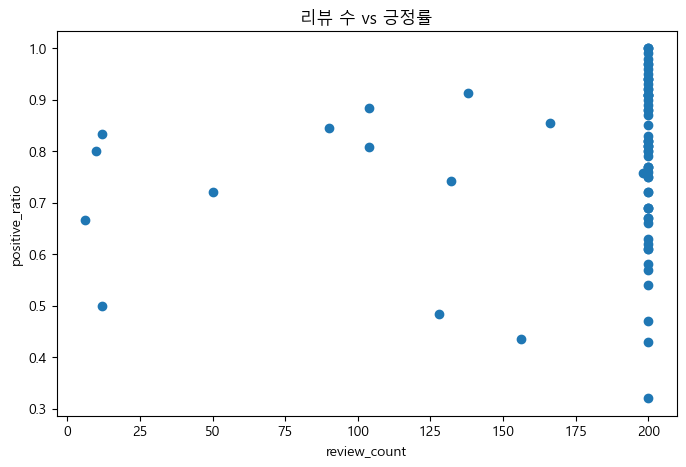

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df['review_count'], df['positive_ratio'])
plt.xlabel("review_count")
plt.ylabel("positive_ratio")
plt.title("리뷰 수 vs 긍정률")
plt.show()

플레이타임 vs 긍정률 시각화

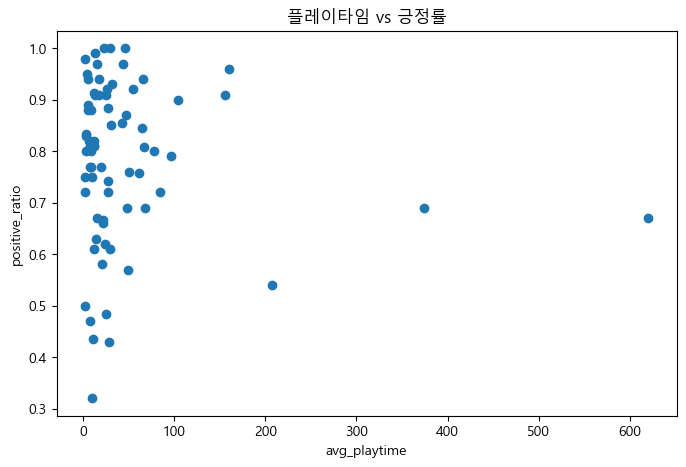

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(df['avg_playtime'], df['positive_ratio'])
plt.xlabel("avg_playtime")
plt.ylabel("positive_ratio")
plt.title("플레이타임 vs 긍정률")
plt.show()

strata 별 긍정률 비교

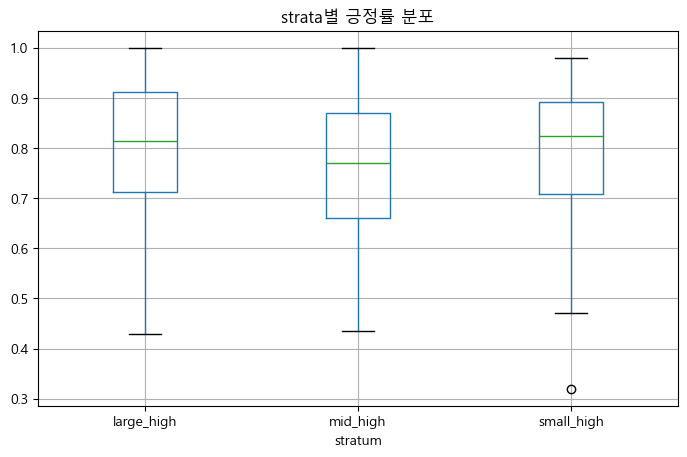

In [12]:
df.boxplot(column='positive_ratio', by='stratum', figsize=(8,5))
plt.title("strata별 긍정률 분포")
plt.suptitle('')
plt.show()

통계검정 Kruskal-Wallis 

In [13]:
groups = [
    g['positive_ratio'].dropna().values
    for _, g in df.groupby('stratum')
]

stat, p = stats.kruskal(*groups)

print("Kruskal-Wallis stat:", stat)
print("p-value:", p)

Kruskal-Wallis stat: 1.385896628380903
p-value: 0.5000994430723606


p > 0.05
starta 간에 차이가 있다고 보기 어려움

In [14]:
# 리뷰와 긍정율, 풀레이 타임간의 상관관계 분석
corr = df[['review_count', 'positive_ratio', 'avg_playtime']].corr()
print(corr)

                review_count  positive_ratio  avg_playtime
review_count        1.000000        0.145703      0.108619
positive_ratio      0.145703        1.000000     -0.083249
avg_playtime        0.108619       -0.083249      1.000000


review_count ↔ positive_ratio :
약한 상관관계

리뷰가 많다고 무조건 좋은 게임이라고 보기는 어렵다

review_count ↔ avg_playtime :
약한 상관관계

많이 리뷰된 게임이라고 해서 유저가 오래 플레이 한다고 보기는 어렵다


positive_ratio ↔ avg_playtime :
약한 음의 상관관계

평가가 좋은게임이라고 해서 플레이 타임이 길다고 볼 수는 없다

review_count, positive_ratio, avg_playtime 간 상관계수는 모두 절대값 0.15 이하로 나타났다
즉 리뷰 수, 긍정률, 평균 플레이타임 사이에 뚜렷한 선형 관계는 거의 보이지 않는다

근데 이건 게임의 장르나 특징이 달라서 그런거 아닌가? 추가분석이 필요할듯

게임중에 짧지만 만족스러운 게임이 있을거고 오래했지만 불만스러운 게임도 있을것
혹은 멀티 플레이 형식 게임이라 오래했는데 평가가 갈리는 것도 있을것

또한 리뷰수는 인기도지만 긍정률은 만족도 지표로볼수있다
따라서 둘은 강하게 연관이 없을수도....

즉 다른 요인도 한번 살펴보자

PS. 층계별로 리뷰수 긍정율, 플레이타임의 관계를 한번 살펴보자

In [16]:
for s in df['stratum'].dropna().unique():
    temp = df[df['stratum'] == s]
    print(s)
    print(temp[['review_count', 'positive_ratio', 'avg_playtime']].corr())
    print()

large_high
                review_count  positive_ratio  avg_playtime
review_count        1.000000        0.095006      0.083613
positive_ratio      0.095006        1.000000     -0.204444
avg_playtime        0.083613       -0.204444      1.000000

mid_high
                review_count  positive_ratio  avg_playtime
review_count        1.000000        0.425348     -0.081835
positive_ratio      0.425348        1.000000      0.196079
avg_playtime       -0.081835        0.196079      1.000000

small_high
                review_count  positive_ratio  avg_playtime
review_count        1.000000       -0.140013      0.085031
positive_ratio     -0.140013        1.000000     -0.267497
avg_playtime        0.085031       -0.267497      1.000000



large_high 그룹은 거의 다 약하다

review_count ↔ positive_ratio = 0.095
거의 관계 없다
큰 게임군에서는 리뷰 수와 만족도가 거의 별개일 수 있다

review_count ↔ avg_playtime = 0.084
거의 관계 없다
큰 게임군에서는 많이 알려진 게임과 오래 붙잡는 게임이 꼭 같은 건 아니다

positive_ratio ↔ avg_playtime = -0.204
약한 음의 관계
큰 게임군에서는 오래 한다고 꼭 더 좋아하는 것은 아닐 수 있다

mid_high 에서는
리뷰 수가 많은 게임일수록 긍정률도 높은 경향이 어느 정도 보인다

review_count ↔ positive_ratio = 0.425
중간에 가까운 양의 관계
중간 규모 상위 게임에서는 사람들이 많이 반응한 게임이 실제로 평가도 좋은 경우가 더 많다

review_count ↔ avg_playtime = -0.082
거의 관계 없다
mid_high 에서도 관심도와 체류시간은 같은 개념이 아니다

positive_ratio ↔ avg_playtime = 0.196
약한 양의 관계
mid_high 에서는 좋은 평가를 받는 게임이 유저를 조금 더 오래 붙잡는 경향이 있을 가능성이 있다

small_high 에서는
긍정률이 높다고 해서 리뷰 수나 플레이타임이 같이 높아지는 구조가 아니다.
오히려 약한 음의 방향이 보인다.

review_count ↔ positive_ratio = -0.140
아주 약한 음의 관계
작은 게임군에서는 리뷰가 늘어나는 것이 꼭 더 좋은 평가로 이어지지 않을 수 있다

review_count ↔ avg_playtime = 0.085
거의 관계 없다
리뷰 수와 플레이타임은 사실상 별개다

positive_ratio ↔ avg_playtime = -0.267
약한 음의 관계
작은 게임군에서는 플레이 시간이 길다고 반드시 평가가 좋은 게 아니다
오히려 짧고 만족스러운 경험이 더 높은 평가로 이어질 가능성도 있다

정리 
1. mid_high 만 review_count와 positive_ratio가 뚜렷하게 같이 움직임
    - 중간 규모의 게임군에서는 많이 리뷰된 게임 = 더 좋은 평가를받은 게임 이라는 경향을 보인다

2. large_high와 small_high는 리뷰 수가 만족도를 잘 설명하지 못함
    - 아마 큰 게임군에서는 홍보나 마케팅등의 외부요인이 많고 작은게임군에서는 변동성이커서
    리뷰수만으로는 쳥가를 예측하기가 어렵다

3. positive_ratio와 avg_playtime 관계는 전체적으로 강하지 않음
    - large_high: -0.204
    - mid_high: 0.196
    - small_high: -0.267
    - 플레이타임은 긍정률을 일관되게 설명하는 변수는 아니다
    오래 한 게임이 무조건 좋은 평가를 받는 것도 아니고
    짧게 한 게임이 무조건 나쁜 평가를 받는 것도 아니다

# 장르별로 나눠서 리뷰수, 긍정률, 플레이 타임의 상관 관계 분석